# sim-app tutorial

This notebook demonstrates the app-facing `sim_app` workflow:

1. generate one synthetic spatial-transcriptomics dataset,
2. inspect the returned `AnnData`,
3. plot aligned and unaligned coordinates,
4. save the result as `.h5ad`.

It uses small settings so the tutorial stays interactive.

## Setup

From the repository root, create the tutorial environment before opening this notebook:

```bash
bash env/create_tutorial_env.sh
conda activate sim-app-tutorial
jupyter-notebook --no-browser --ip=0.0.0.0 --port 8888
```

In [6]:
from pathlib import Path
import sys

def find_repo_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file() and (candidate / "sim_app" / "__init__.py").is_file():
            return candidate
        nested = candidate / "sim_app"
        if (nested / "pyproject.toml").is_file() and (nested / "sim_app" / "__init__.py").is_file():
            return nested
    raise RuntimeError("Could not find the sim_app repository root.")

repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

sys.modules.pop("sim_app", None)
import sim_app

print("Python:", sys.executable)
print("sim_app module:", getattr(sim_app, "__file__", "<no __file__>"))
print("sim_app version:", getattr(sim_app, "__version__", "<no __version__>"))
print("has generate_data:", hasattr(sim_app, "generate_data"))
print("public names:", [name for name in dir(sim_app) if not name.startswith("_")][:30])

Python: /dcs04/hicks/data/Jan/sim_project/sim_app/env/sim-app-tutorial/bin/python
sim_app module: /dcs04/hicks/data/Jan/sim_project/sim_app/sim_app/__init__.py
sim_app version: 0.1.0
has generate_data: True
public names: ['DEFAULT_PARAMETERS', 'api', 'describe', 'example_data', 'generate_data', 'plot', 'plotting', 'save', 'simulate_3d_molecule_sphere_multires', 'simulation_sphere']


## Generate a small bin-level dataset

`generate_data()` returns exactly one `AnnData` object for the requested output type and slice axis.

In [ ]:
adata = sim_app.generate_data(
    output="bin",
    slice_axis="Z",
    n_cells=10000,
    n_slices=3,
    n_domains=4,
    marker_genes_per_type=20,
    sphere_radius_um=200.0,
    capture_window_um=(300.0, 300.0),
    bin_size_um=30.0,
    seed=2025,
)

adata

## Inspect the returned object

`describe()` gives a compact summary of the app-relevant fields.

In [8]:
summary = sim_app.describe(adata)
summary

{'n_obs': 300,
 'n_vars': 73,
 'total_counts': 84432,
 'nonzero_counts': 9745,
 'platform': 'bin',
 'slice_axis': 'Z',
 'n_slices': 3,
 'slice_ids': [0, 1, 2],
 'obs_columns': ['slice_axis',
  'slice_id',
  'bin_size_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors',
  'rigid_perturb_inplane',
  'sim_params',
  'output'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

In [9]:
adata.obs.head()

,slice_axis,slice_id,bin_size_um,window_center0,window_center1,window_size0,window_size1,plane_dim0,plane_dim1,cell_type_true,domain_true
0,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type1,D0
1,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type1,D0
2,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type1,D0
3,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type3,D1
4,Z,0,30.0,0.0,0.0,300.0,300.0,X,Y,type2,D1


In [10]:
adata.var.head()

,gene_class,is_noise,is_shared_marker
G1,marker_shared,False,True
G2,marker_shared,False,True
G3,marker_shared,False,True
G4,marker_shared,False,True
G5,marker_shared,False,True


## Plot aligned and unaligned coordinates

`plot()` returns a Matplotlib figure. Use `coordinates="aligned"` for canonical tissue coordinates and `coordinates="unaligned"` for the per-slice rigid transforms.

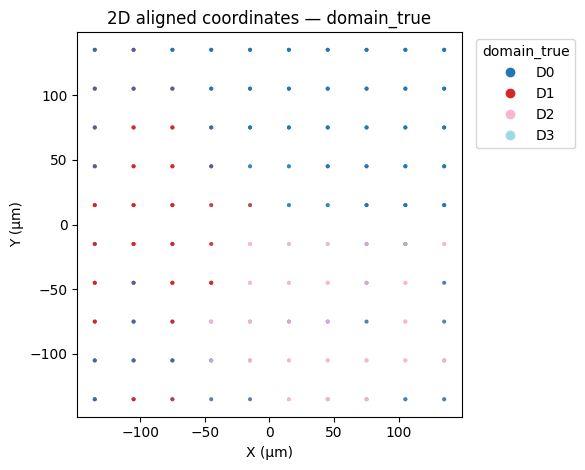

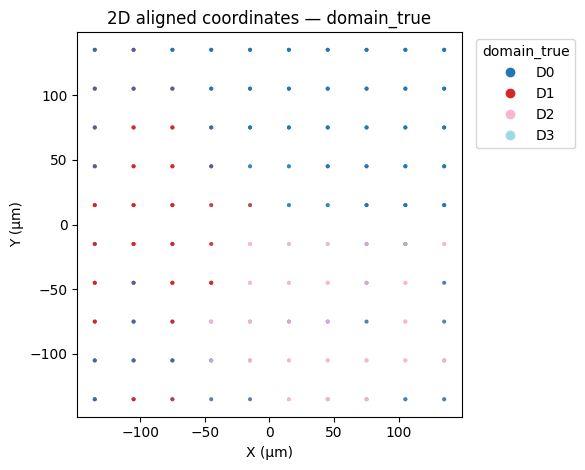

In [11]:
fig = sim_app.plot(
    adata,
    view="2d",
    coordinates="aligned",
    color="domain_true",
    point_size=8,
)
fig

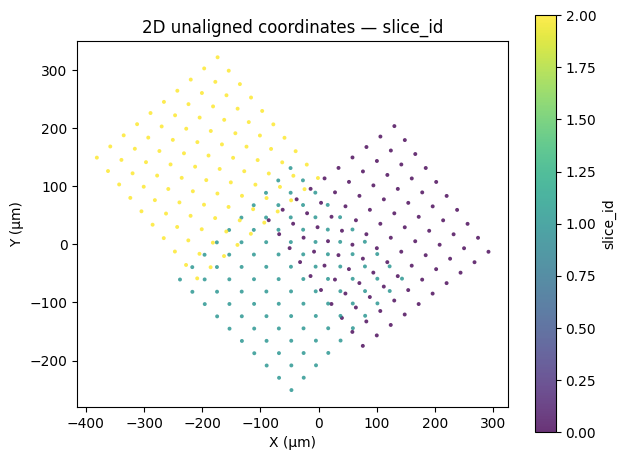

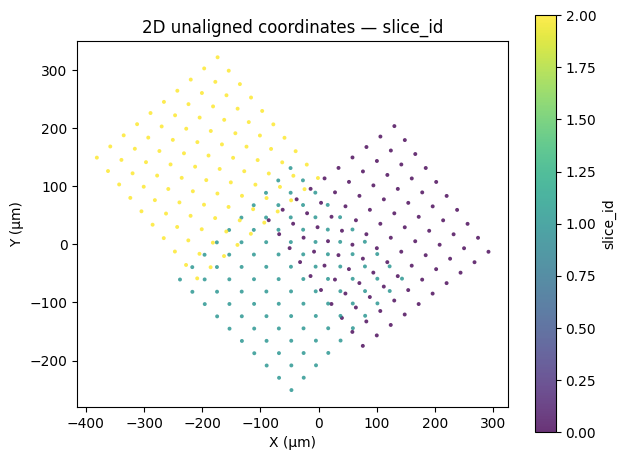

In [12]:
fig = sim_app.plot(
    adata,
    view="2d",
    coordinates="unaligned",
    color="slice_id",
    point_size=8,
)
fig

## Generate other app outputs

Use the same public API for spot-level or cell-level data. Only the requested output is generated.

In [13]:
spot_adata = sim_app.example_data(output="spot", slice_axis="Y", n_cells=200)
sim_app.describe(spot_adata)

{'n_obs': 48,
 'n_vars': 289,
 'total_counts': 49132,
 'nonzero_counts': 5784,
 'platform': 'spot',
 'slice_axis': 'Y',
 'n_slices': 3,
 'slice_ids': [0, 1, 2],
 'obs_columns': ['slice_axis',
  'slice_id',
  'spot_spacing_um',
  'spot_radius_um',
  'window_center0',
  'window_center1',
  'window_size0',
  'window_size1',
  'plane_dim0',
  'plane_dim1',
  'cell_type_true',
  'domain_true'],
 'var_columns': ['gene_class', 'is_noise', 'is_shared_marker'],
 'layers': ['counts_pre_batch'],
 'obsm_keys': ['spatial',
  'cell_type_frac_true',
  'domain_frac_true',
  'spatial_3d',
  'spatial_unaligned',
  'spatial_3d_unaligned'],
 'uns_keys': ['batch_effect_factors',
  'rigid_perturb_inplane',
  'sim_params',
  'output'],
 'truth_annotations': ["layers['counts_pre_batch']",
  "obs['cell_type_true']",
  "obs['domain_true']",
  "obsm['cell_type_frac_true']",
  "obsm['domain_frac_true']"]}

In [ ]:
cell_adata = sim_app.example_data(output="cell", slice_axis="X", n_cells=200)
sim_app.describe(cell_adata)

## Save the result

`save()` writes the object with AnnData's `.h5ad` format and returns the output path.

In [ ]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

output_path = sim_app.save(adata, output_dir / "simulation_bins_z.h5ad")
output_path